# XCT Membrane Segmentation — Weak Labels + Napari Correction

**Goal:** from a ~4000-slice XCT reconstructed tif stack containing three phases
(voidage < membrane < polymer cartridge, in increasing attenuation), produce:

1. A random sample of 50 slices for annotation.
2. An automatic first-pass 3-class segmentation mask for those 50 slices, using
   the fact that the phases separate by grey-value (multi-Otsu thresholding),
   with denoising and morphological cleanup.
3. A napari-based correction workflow so you can clean up the auto-mask by hand.
4. Image/mask pairs on disk, ready to use as training data for a supervised
   segmentation model later.

**You will need to edit the `CONFIG` cell below** to point at your actual data —
this notebook was built without access to your files, so paths/filenames are
placeholders.

Assumes the data is a **single multi-page tif** (one file containing all ~4000
slices), read lazily page-by-page so the whole volume never has to sit in
memory at once. If you instead have a folder of individually numbered tif
slices, see the note in the "Load stack" section for the one-function swap.


## How to use this notebook

**Pipeline position:** notebook **1 of 3**. Run this first — it turns a raw XCT
tif stack into a labelled training set. `xct_unet_training.ipynb` trains a model
on the output of this notebook, and `inspect_mask_values.ipynb` is a small
standalone helper for spot-checking any mask file afterwards.

**What it does, in order:**

1. Randomly samples 50 slices from your stack.
2. Auto-segments those 50 slices with multi-Otsu thresholding (fast, but only
   grey-value-aware — expect rough edges).
3. Lets you hand-correct each auto-mask in napari.
4. Saves everything to `CONFIG["output_dir"]` as an image/mask training set
   (`images/`, `masks_corrected/`, `sample_manifest.csv`).

**Before running, edit the `CONFIG` cell (section 1) below.** At minimum:

| Variable | What to set it to |
|---|---|
| `stack_path` | Path to your multi-page tif stack |
| `output_dir` | Where images, masks, and the manifest should be written |
| `n_samples` | How many slices to sample for annotation (50 is a reasonable start) |
| `phase_names` / `n_classes` | Only change if your material has a different number of phases |

Everything else in `CONFIG` (denoising, thresholding, morphological cleanup)
has working defaults — tune them only if the QC preview in section 7 looks off.

**Workflow:** run sections 0–7 once. Then repeat section 8 (napari correction)
across multiple sittings until enough of the 50 samples are corrected — the
notebook picks up wherever you left off via `sample_manifest.csv`, so it's
safe to close and reopen at any point. See "Resuming on a later day" below
section 8 for the exact steps.


## 0. Setup

Install/check dependencies. napari is only needed for the manual-correction step.

In [1]:
# pip install tifffile scikit-image scipy numpy matplotlib pandas tqdm napari scikit-learn

import os
import re
import json
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from tqdm.auto import tqdm

from scipy.ndimage import median_filter, binary_fill_holes
from skimage.filters import threshold_multiotsu
from skimage.morphology import remove_small_objects, remove_small_holes, disk, binary_opening, binary_closing
from skimage.color import label2rgb
from skimage.feature import multiscale_basic_features
from sklearn.ensemble import RandomForestClassifier


## 1. Config

Edit these paths and parameters for your dataset.

In [ ]:
CONFIG = {
    # --- paths ---
    "stack_path": Path("path/to/stack/"),   # single multi-page tif, ~4000 pages
    "output_dir": Path("path/to/output"),

    # --- sampling ---
    "n_samples": 50,
    "random_seed": 42,

    # --- phases (ordered by increasing attenuation / grey value) ---
    "phase_names": ["voidage", "membrane", "polymer_cartridge"],
    "n_classes": 3,

    # --- preprocessing ---
    "denoise_median_size": 3,       # median filter kernel size (odd int), 0/None to skip

    # --- threshold estimation ---
    "n_slices_for_histogram": 60,   # how many slices to sample when estimating global thresholds
                                     # (uses the 50 annotation samples + a few extra for robustness)

    # --- morphological cleanup ---
    "min_object_size_px": 64,       # remove connected components smaller than this, per class
    "min_hole_size_px": 64,         # fill holes smaller than this, per class
    "closing_radius": 1,            # structuring element radius for binary closing (0 to skip)

    # --- classifier bootstrap (section 8b) ---
    "max_train_pixels_per_sample": 200_000,  # cap per corrected sample fed into the random forest
                                              # (~4M px/slice otherwise — fit time would grow linearly
                                              # as you correct more samples). None = use every pixel.
}

CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)
(CONFIG["output_dir"] / "images").mkdir(exist_ok=True)
(CONFIG["output_dir"] / "masks_auto").mkdir(exist_ok=True)
(CONFIG["output_dir"] / "masks_corrected").mkdir(exist_ok=True)
CONFIG


{'stack_path': PosixPath('/home/charlie/usb_drive/data/Stitched/3_stitches_stitched.tif'),
 'output_dir': PosixPath('/home/charlie/usb_drive/data/Masks/segmentation_mask_1'),
 'n_samples': 50,
 'random_seed': 42,
 'phase_names': ['voidage', 'membrane', 'polymer_cartridge'],
 'n_classes': 3,
 'denoise_median_size': 3,
 'n_slices_for_histogram': 60,
 'min_object_size_px': 64,
 'min_hole_size_px': 64,
 'closing_radius': 1,
 'max_train_pixels_per_sample': 200000}

## 2. Locate the stack

Opens the multi-page tif once and keeps it open for the rest of the notebook.
Pages are read lazily (`tif_file.pages[idx].asarray()`), so nothing forces the
whole ~4000-slice volume into memory — only the pages you actually touch get
decoded.

**Folder of individually numbered slices instead?** Replace this cell and
`load_slice()` below with:

```python
def natural_key(path):
    nums = re.findall(r"\d+", path.stem)
    return [int(n) for n in nums] if nums else [path.stem]

slice_paths = sorted(CONFIG["stack_dir"].glob("*.tif"), key=natural_key)
n_total = len(slice_paths)

def load_slice(idx):
    return tifffile.imread(slice_paths[idx])
```

everything downstream only relies on `n_total` and `load_slice(idx)`, so
nothing else in the notebook needs to change.


In [3]:
tif_file = tifffile.TiffFile(CONFIG["stack_path"])
n_total = len(tif_file.pages)
print(f"Found {n_total} pages in {CONFIG['stack_path']}")
assert n_total > 0, "No pages found — check stack_path in CONFIG."

# peek at one slice for shape/dtype
probe = tif_file.pages[n_total // 2].asarray()
print(f"Slice shape: {probe.shape}, dtype: {probe.dtype}, "
      f"min/max: {probe.min()}/{probe.max()}")


Found 4692 pages in /home/charlie/usb_drive/data/Stitched/3_stitches_stitched.tif
Slice shape: (2028, 2028), dtype: uint16, min/max: 10683/20089


In [4]:
def load_slice(idx):
    """Load a single slice as a 2D numpy array by page index."""
    return tif_file.pages[idx].asarray()


## 3. Random sample of 50 slices

Sampled uniformly from the *whole* stack. If you know the top/bottom end-caps
of the volume don't follow the 3-phase assumption (e.g. mounting hardware,
air gaps at the ends), set `exclude_ranges` to skip those index ranges.

**Resuming a previous session:** this cell is safe to re-run on a later day —
if `sample_manifest.csv` already exists in `output_dir` it's loaded from disk
instead of being regenerated, so your `corrected` progress isn't reset. (Even
without the CSV, re-running with the same `random_seed` reproduces the same
50 indices, since the RNG is seeded — but loading the saved manifest is the
safer path because it also carries forward which samples you've already
corrected.)


In [5]:
exclude_ranges = []  # e.g. [(0, 100), (3900, 4000)] to exclude first/last 100 slices

manifest_path = CONFIG["output_dir"] / "sample_manifest.csv"

# always defined, regardless of which branch below runs — section 4 (histogram
# thresholds) reuses both to pick extra slices beyond the 50 annotation samples
valid_indices = [i for i in range(n_total)
                  if not any(lo <= i < hi for lo, hi in exclude_ranges)]
rng = np.random.default_rng(CONFIG["random_seed"])

if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    sample_indices = manifest["slice_index"].tolist()
    print(f"Resumed existing manifest from {manifest_path} "
          f"({manifest['corrected'].sum()}/{len(manifest)} already corrected)")
else:
    sample_indices = sorted(rng.choice(valid_indices, size=CONFIG["n_samples"], replace=False).tolist())

    manifest = pd.DataFrame({
        "sample_id": range(len(sample_indices)),
        "slice_index": sample_indices,
        "filename": [f"slice_{i:05d}.tif" for i in sample_indices],  # synthetic — single stack has no per-slice filenames
        "corrected": False,
        "corrected_at": None,
    })
    manifest.to_csv(manifest_path, index=False)
    print(f"Sampled {len(sample_indices)} slices, manifest saved to {manifest_path}")

manifest.head()


Resumed existing manifest from /home/charlie/usb_drive/data/Masks/segmentation_mask_1/sample_manifest.csv (40/50 already corrected)


,sample_id,slice_index,filename,corrected,corrected_at
0,10,1062,slice_01062.tif,True,2026-07-29T11:15:30
1,11,1295,slice_01295.tif,True,2026-07-29T12:06:57
2,12,1661,slice_01661.tif,True,2026-07-29T13:58:16
3,13,1729,slice_01729.tif,True,2026-07-29T16:55:02
4,14,1878,slice_01878.tif,True,2026-07-29T18:08:48


## 4. Estimate global multi-Otsu thresholds

Because voidage / membrane / polymer separate by attenuation, a global grey-value
threshold (fit once, applied everywhere) should be far more consistent slice-to-slice
than refitting per slice. Thresholds are estimated from a pooled histogram over the
50 annotation samples plus a few extra random slices for robustness, each lightly
denoised first so a handful of hot/dead pixels don't skew the histogram.


In [6]:
def denoise(img):
    size = CONFIG["denoise_median_size"]
    if not size:
        return img
    return median_filter(img, size=size)

n_extra = max(0, CONFIG["n_slices_for_histogram"] - len(sample_indices))
extra_indices = rng.choice(
    [i for i in valid_indices if i not in sample_indices],
    size=min(n_extra, len(valid_indices) - len(sample_indices)),
    replace=False,
).tolist() if n_extra > 0 else []

hist_indices = sample_indices + extra_indices
pooled = np.concatenate([denoise(load_slice(i)).ravel() for i in tqdm(hist_indices, desc="Pooling histogram")])

thresholds = threshold_multiotsu(pooled, classes=CONFIG["n_classes"])
print("Global thresholds:", thresholds)


Pooling histogram:   0%|          | 0/60 [00:00<?, ?it/s]

Global thresholds: [12425 14442]


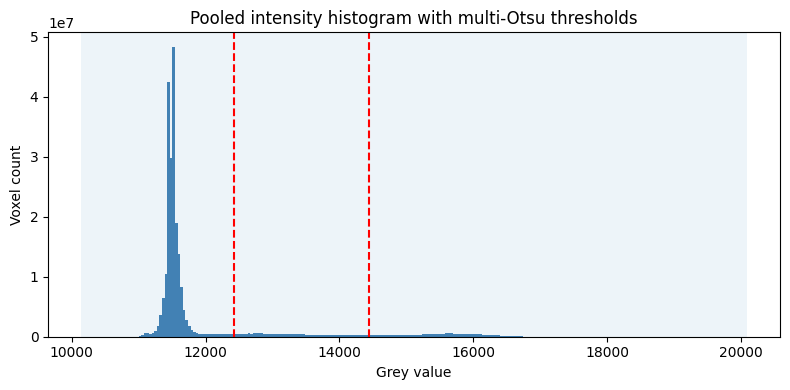

In [7]:
# Sanity-check plot: pooled intensity histogram with thresholds overlaid
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pooled, bins=256, color="steelblue")
for t in thresholds:
    ax.axvline(t, color="red", linestyle="--")
ax.set_title("Pooled intensity histogram with multi-Otsu thresholds")
ax.set_xlabel("Grey value")
ax.set_ylabel("Voxel count")
for name, lo, hi in zip(CONFIG["phase_names"],
                         [pooled.min()] + list(thresholds),
                         list(thresholds) + [pooled.max()]):
    ax.axvspan(lo, hi, alpha=0.08)
plt.tight_layout()
plt.show()

del pooled  # free memory


## 5. Segmentation function

Denoise → apply global thresholds → per-class morphological cleanup (remove
small islands, fill small holes, optional closing). Labels: `0 = voidage`,
`1 = membrane`, `2 = polymer_cartridge` (order follows `CONFIG["phase_names"]`,
i.e. increasing attenuation).


In [8]:
def cleanup_labels(labels):
    """Per-class small-object/hole cleanup. Shared by the Otsu segmenter
    below and by the classifier-based mask refresh in section 8b."""
    cleaned = np.zeros_like(labels)
    selem = disk(CONFIG["closing_radius"]) if CONFIG["closing_radius"] else None

    for class_id in range(CONFIG["n_classes"]):
        mask = labels == class_id
        mask = remove_small_objects(mask, min_size=CONFIG["min_object_size_px"])
        mask = remove_small_holes(mask, area_threshold=CONFIG["min_hole_size_px"])
        if selem is not None:
            mask = binary_closing(mask, selem)
        cleaned[mask] = class_id

    return cleaned

def segment_slice(img, thresholds=thresholds):
    denoised = denoise(img)
    labels = np.digitize(denoised, bins=thresholds).astype(np.uint8)
    return cleanup_labels(labels)

def overlay(img, labels):
    img_norm = (img - img.min()) / max(1, (img.max() - img.min()))
    # cast to a signed dtype — label2rgb computes `labels - bg_label` internally,
    # which overflows uint8 when bg_label=-1
    return label2rgb(labels.astype(np.int32), image=img_norm, bg_label=-1, alpha=0.35)


## 6. Run on the 50 sampled slices, save image + auto-mask pairs

Raw slice → `images/`, auto-generated label mask → `masks_auto/` (also copied
to `masks_corrected/` as the starting point you'll edit in napari).

**Safe to re-run** on a later day or after a kernel restart: `masks_auto/` is
always refreshed (it's meant to reflect the current Otsu settings), but
`masks_corrected/` is only written the *first* time for a given sample — if
you've already corrected (or classifier-refreshed) a sample, this loop will
not touch its `masks_corrected/` file and your work is preserved.


In [9]:
def sample_filename(row):
    """The on-disk filename for a manifest row — used consistently by every
    section below so images/masks_auto/masks_corrected always agree on naming."""
    return f"sample_{row.sample_id:03d}_{Path(row.filename).stem}.tif"

n_skipped = 0
for _, row in tqdm(list(manifest.iterrows()), desc="Segmenting samples"):
    img = load_slice(row.slice_index)
    mask = segment_slice(img)

    out_name = sample_filename(row)
    tifffile.imwrite(CONFIG["output_dir"] / "images" / out_name, img)
    tifffile.imwrite(CONFIG["output_dir"] / "masks_auto" / out_name, mask)

    corrected_path = CONFIG["output_dir"] / "masks_corrected" / out_name
    if corrected_path.exists():
        n_skipped += 1
    else:
        tifffile.imwrite(corrected_path, mask)  # editable copy — first time only

print(f"Done. Image/mask pairs written to: {CONFIG['output_dir']} "
      f"({n_skipped} masks_corrected file(s) left untouched — already had work on them)")


Segmenting samples:   0%|          | 0/50 [00:00<?, ?it/s]

Done. Image/mask pairs written to: /home/charlie/usb_drive/data/Masks/segmentation_mask_1 (50 masks_corrected file(s) left untouched — already had work on them)


## 7. QC: spot-check a few auto-masks before correcting

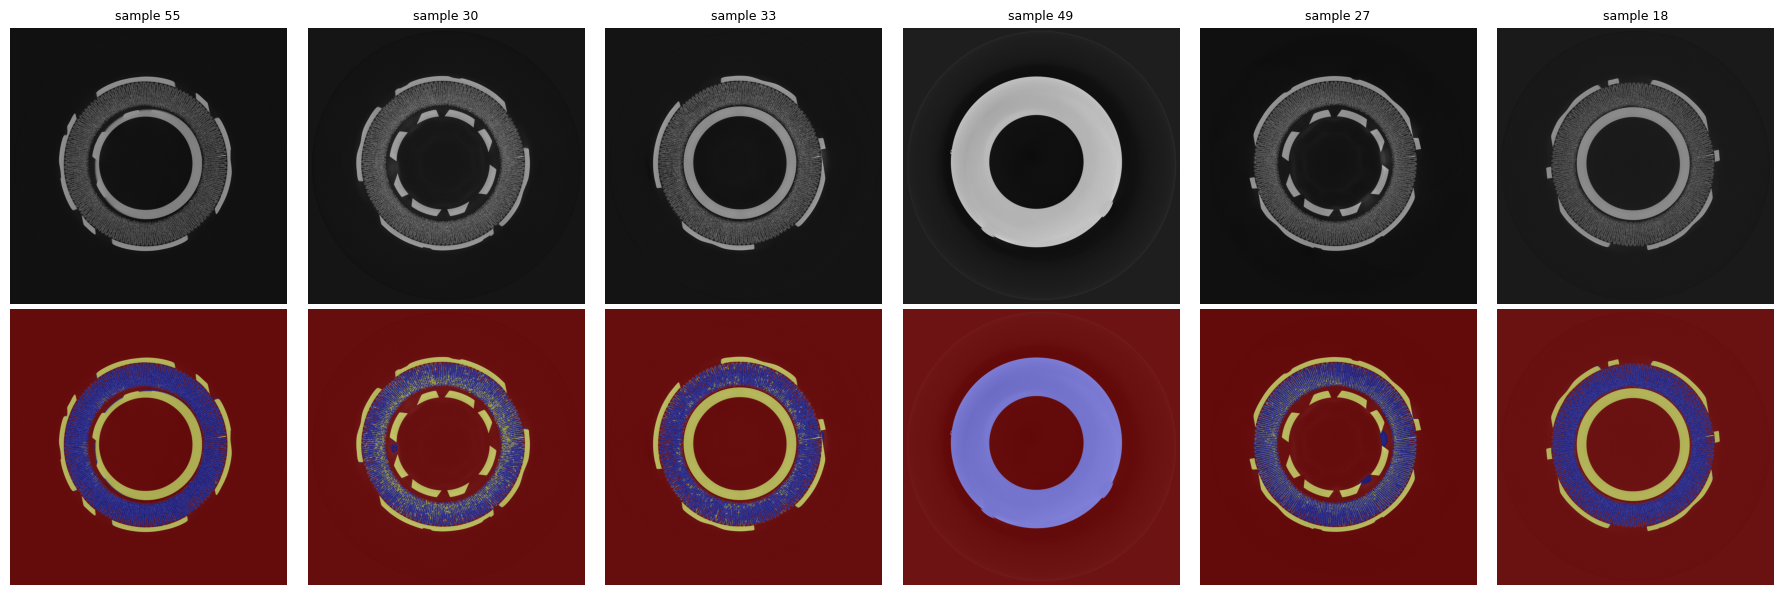

In [10]:
n_preview = 6
preview_ids = rng.choice(manifest["sample_id"], size=min(n_preview, len(manifest)), replace=False)

fig, axes = plt.subplots(2, len(preview_ids), figsize=(3 * len(preview_ids), 6))
for col, sid in enumerate(preview_ids):
    row = manifest.loc[manifest.sample_id == sid].iloc[0]
    img = load_slice(row.slice_index)
    mask = segment_slice(img)

    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"sample {sid}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay(img, mask))
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel("auto mask")
plt.tight_layout()
plt.show()


## 8. Manual correction in napari

Workflow per sample:

1. `open_for_correction(sample_id)` — opens napari with the raw slice and the
   editable label mask loaded as a `Labels` layer. Use napari's paintbrush /
   eraser / fill tools to correct the mask (napari's default label colours are
   arbitrary — check `CONFIG["phase_names"]` for which integer is which phase).
2. Edit directly in the napari window.
3. `save_correction(sample_id)` — grabs the current state of the labels layer
   from the open viewer and writes it to `masks_corrected/`, and marks the
   sample as corrected in the manifest.
4. Repeat for the next `sample_id`.

Run `%gui qt` once first so napari doesn't block the notebook kernel.


In [11]:
%gui qt
import napari

_active_viewers = {}  # sample_id -> napari.Viewer

def open_for_correction(sample_id):
    row = manifest.loc[manifest.sample_id == sample_id].iloc[0]
    fname = sample_filename(row)

    img = tifffile.imread(CONFIG["output_dir"] / "images" / fname)
    mask = tifffile.imread(CONFIG["output_dir"] / "masks_corrected" / fname)

    viewer = napari.Viewer(title=f"sample {sample_id} — {fname}")
    viewer.add_image(img, name="raw", colormap="gray")
    viewer.add_labels(mask, name="mask", opacity=0.45)
    _active_viewers[sample_id] = (viewer, fname)
    print(f"Opened sample {sample_id} ({fname}). Edit the 'mask' labels layer, "
          f"then call save_correction({sample_id}).")
    return viewer

def save_correction(sample_id):
    if sample_id not in _active_viewers:
        raise ValueError(f"No open viewer for sample {sample_id} — call open_for_correction first.")
    viewer, fname = _active_viewers[sample_id]
    edited_mask = viewer.layers["mask"].data.astype(np.uint8)

    tifffile.imwrite(CONFIG["output_dir"] / "masks_corrected" / fname, edited_mask)
    manifest.loc[manifest.sample_id == sample_id, "corrected"] = True
    manifest.loc[manifest.sample_id == sample_id, "corrected_at"] = datetime.now().isoformat(timespec="seconds")
    if "flagged_for_review" in manifest.columns:  # no-op until the review section (below) has been run once
        manifest.loc[manifest.sample_id == sample_id, "flagged_for_review"] = False
    manifest.to_csv(manifest_path, index=False)

    viewer.close()
    del _active_viewers[sample_id]
    print(f"Saved corrected mask for sample {sample_id} -> {fname}")


### 8b. Speed up the remaining corrections using what you've already fixed

Hand-correcting each of the 50 slices from the raw Otsu mask is slow because
that mask only knows about grey value — it has no sense of shape, edges, or
texture, so every blob boundary needs manual attention. Once you have even
one fully-corrected slice, you have real ground truth: fit a small classifier
on it (random forest over multiscale intensity/edge/texture features, the
same idea behind ilastik's pixel classification) and use it to re-predict
starting masks for every sample you *haven't* corrected yet. Those
predictions should already be close, so napari correction becomes touch-up
rather than painting from scratch.

Call `refresh_remaining_masks_with_classifier()` after finishing each new
correction — it retrains on every sample marked `corrected` so far (so it
keeps improving as you go) and overwrites `masks_corrected/` for everything
still outstanding. It leaves already-corrected samples untouched.

**Feature caching:** `multiscale_basic_features` (Gaussian/edge/Hessian
filtering across several scales) is the expensive step here, and it only
depends on the *raw image*, never the mask — so it's identical every time you
call this for a given sample, regardless of how many times that sample's
correction changes. Without caching, every call recomputes it for every
corrected sample from scratch, which quietly gets slower the further you get
through the 50. `get_features()` below caches each sample's features to disk
the first time and reuses them after that. Features are stored as `float32`
(halves both memory and cache size vs the default `float64`, with no
meaningful accuracy cost for this).

One thing to watch: each cached feature array is still large — roughly
150-250MB per sample at `float32` for a ~2000x2000 slice — so the cache
folder can reach several GB by sample 50. If `output_dir` is on the USB
drive, that's extra read/write traffic on what's likely your slowest disk;
if it becomes a problem, point `feature_cache_dir` at a folder on your
internal disk instead.


In [12]:
_classifier = None

FEATURE_CACHE_DIR = CONFIG["output_dir"] / "features_cache"  # move to internal disk if output_dir is on a slow drive
FEATURE_CACHE_DIR.mkdir(exist_ok=True)

def _slice_features(img):
    feats = multiscale_basic_features(
        img, intensity=True, edges=True, texture=True,
        sigma_min=1, sigma_max=8, channel_axis=None,
    )
    return feats.astype(np.float32)

def get_features(fname, img):
    """Cached wrapper around _slice_features. Features depend only on the raw
    image, not the mask, so they're safe to reuse across every train/refresh
    call no matter how many times that sample gets re-corrected."""
    cache_path = FEATURE_CACHE_DIR / f"{Path(fname).stem}.npy"
    if cache_path.exists():
        return np.load(cache_path)
    feats = _slice_features(img)
    np.save(cache_path, feats)
    return feats

def train_classifier_from_corrected():
    """Fit a random forest on every sample currently marked corrected.

    Subsamples pixels per sample (CONFIG["max_train_pixels_per_sample"]) so
    fit time stays roughly constant as you correct more of the 50, rather
    than growing linearly with every new sample (~4M px/slice otherwise)."""
    global _classifier
    corrected = manifest.loc[manifest.corrected]
    if corrected.empty:
        print("No corrected samples yet — correct at least one before calling this.")
        return None

    cap = CONFIG.get("max_train_pixels_per_sample", 200_000)  # default even if an older CONFIG cell is in use
    rng_train = np.random.default_rng(CONFIG["random_seed"])

    X_parts, y_parts = [], []
    for _, row in corrected.iterrows():
        fname = sample_filename(row)
        img = tifffile.imread(CONFIG["output_dir"] / "images" / fname)
        mask = tifffile.imread(CONFIG["output_dir"] / "masks_corrected" / fname)
        feats = get_features(fname, img)

        X_i = feats.reshape(-1, feats.shape[-1])
        y_i = mask.ravel()

        if cap is not None and len(y_i) > cap:
            idx = rng_train.choice(len(y_i), size=cap, replace=False)
            X_i, y_i = X_i[idx], y_i[idx]

        X_parts.append(X_i)
        y_parts.append(y_i)

    X = np.concatenate(X_parts)
    y = np.concatenate(y_parts)

    clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=12,
                                  random_state=CONFIG["random_seed"])
    clf.fit(X, y)
    _classifier = clf
    cap_note = f" (capped at {cap:,}/sample)" if cap is not None else ""
    print(f"Trained on {len(corrected)} corrected sample(s), {X.shape[0]:,} pixels{cap_note}.")
    return clf

def refresh_remaining_masks_with_classifier():
    """Re-predict masks_corrected/ for every not-yet-corrected sample using a
    classifier trained on everything corrected so far. Safe to re-run after
    each new correction — already-corrected samples are left untouched."""
    clf = train_classifier_from_corrected()
    if clf is None:
        return

    remaining_rows = manifest.loc[~manifest.corrected]
    for _, row in tqdm(list(remaining_rows.iterrows()), desc="Refreshing starting masks"):
        fname = sample_filename(row)
        img = tifffile.imread(CONFIG["output_dir"] / "images" / fname)
        feats = get_features(fname, img)
        pred = clf.predict(feats.reshape(-1, feats.shape[-1])).reshape(img.shape).astype(np.uint8)
        pred = cleanup_labels(pred)
        tifffile.imwrite(CONFIG["output_dir"] / "masks_corrected" / fname, pred)

    print(f"Refreshed {len(remaining_rows)} starting mask(s) using the classifier.")


In [35]:
# Recommended loop once you have at least 1 corrected sample:
refresh_remaining_masks_with_classifier()   # improve starting masks for everything outstanding
# open_for_correction(remaining[0])
# ... touch up in napari — should need far less painting than the raw Otsu mask ...
# save_correction(remaining[0])
# refresh_remaining_masks_with_classifier()   # retrain including the sample you just finished
# open_for_correction(remaining[1])
# ...


KeyboardInterrupt: 

### 8c. Use U-Net predictions as the starting point instead

If you've trained the U-Net (separate `xct_unet_training.ipynb` notebook,
same `output_dir`) and it's doing a good job on the remaining unlabelled
samples, its predictions in `masks_unet/` are a much better starting point
for correction than either the raw Otsu mask or the in-notebook random
forest — use `load_unet_predictions_into_corrected()` instead of
`refresh_remaining_masks_with_classifier()` from here on. Touch-up in napari
should be lighter still, and every one you save becomes real ground truth
you can feed back into a stronger U-Net retrain later.

Only touches samples not yet marked `corrected` — already-finished ones are
left alone, same as the classifier refresh.


In [39]:
def load_unet_predictions_into_corrected():
    """Overwrite masks_corrected/ for every not-yet-corrected sample with the
    U-Net's predictions from masks_unet/ (written by xct_unet_training.ipynb).
    Safe to re-run — only touches samples still marked uncorrected."""
    unet_dir = CONFIG["output_dir"] / "masks_unet"
    if not unet_dir.exists():
        print(f"No masks_unet/ folder found at {unet_dir} — run the U-Net notebook first.")
        return

    remaining_rows = manifest.loc[~manifest.corrected]
    n_updated, n_missing = 0, 0
    for _, row in remaining_rows.iterrows():
        fname = sample_filename(row)
        src = unet_dir / fname
        if src.exists():
            shutil.copy(src, CONFIG["output_dir"] / "masks_corrected" / fname)
            n_updated += 1
        else:
            n_missing += 1

    msg = f"Loaded U-Net predictions into masks_corrected/ for {n_updated} sample(s)."
    if n_missing:
        msg += f" {n_missing} remaining sample(s) had no matching file in masks_unet/."
    print(msg)


In [40]:
# Recommended loop once the U-Net is trained:
load_unet_predictions_into_corrected()   # swap in U-Net predictions for everything outstanding
# open_for_correction(remaining[0])
# ... touch up in napari — should need only light correction now ...
# save_correction(remaining[0])
# open_for_correction(remaining[1])
# ...
# once you've corrected a meaningful batch, re-run xct_unet_training.ipynb
# to retrain on the larger ground-truth set


Loaded U-Net predictions into masks_corrected/ for 3 sample(s).


### Resuming on a later day

Corrected/uncorrected status lives in `sample_manifest.csv` and each edited
mask is written to `masks_corrected/` as soon as you call `save_correction()`
— nothing is held only in the notebook's memory. So if the notebook or kernel
closes:

1. Re-open the notebook, run **Config**, **Locate the stack**, and **Random
   sample** (section 3) again — section 3 will detect the existing manifest
   and load it rather than starting over, so already-corrected samples stay
   marked as done.
2. Skip straight to this section, re-run the `%gui qt` / function-definitions
   cell and whichever of the 8b classifier-refresh or 8c U-Net-loading cells
   you're using, then use `remaining` below to see what's left.
3. If you were mid-review (8d), re-run that cell too — `review_next()`
   starts over from the beginning of `review_queue` in a fresh kernel (there's
   no persisted position), so use `review_jump(sample_id)` to skip straight
   back to wherever you'd gotten to.


In [45]:
remaining = manifest.loc[~manifest.corrected, "sample_id"].tolist()
print(f"{len(remaining)} of {len(manifest)} samples still need correcting: {remaining}")

# then continue from wherever you left off, e.g.:
open_for_correction(remaining[0])


1 of 50 samples still need correcting: [59]
Opened sample 59 (sample_059_slice_04344.tif). Edit the 'mask' labels layer, then call save_correction(59).


Viewer(camera=Camera(center=(0.0, 1013.5, 1013.5), zoom=0.40332840236686385, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(1.0, 1.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=10.0), dims=Dims(ndim=2, ndisplay=2, order=(0, 1), axis_labels=('0', '1'), rollable=(True, True), range=(RangeTuple(start=0.0, stop=2027.0, step=1.0), RangeTuple(start=0.0, stop=2027.0, step=1.0)), margin_left=(0.0, 0.0), margin_right=(0.0, 0.0), point=(1013.0, 1013.0), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'raw' at 0x7f8aadb51af0>, <Labels layer 'mask' at 0x7f8aadb51b20>], help='use <7> for transform, use <1> for activate the label eraser, use <2> for activate the paint brush, use <3> for activate the polygon tool, use <4> for activate the fill bucket, use <5> for pick mode', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='sample 59 — sample_059_slice_04344.

In [46]:
save_correction(remaining[0])

Saved corrected mask for sample 59 -> sample_059_slice_04344.tif


In [47]:
# Progress check
manifest[["sample_id", "filename", "corrected", "corrected_at"]]


,sample_id,filename,corrected,corrected_at
0,10,slice_01062.tif,True,2026-07-29T11:15:30
1,11,slice_01295.tif,True,2026-07-29T12:06:57
2,12,slice_01661.tif,True,2026-07-29T13:58:16
3,13,slice_01729.tif,True,2026-07-29T16:55:02
4,14,slice_01878.tif,True,2026-07-29T18:08:48
5,15,slice_02012.tif,True,2026-07-30T11:35:11
6,16,slice_02039.tif,True,2026-07-30T11:50:00
7,17,slice_02071.tif,True,2026-07-30T12:06:32
8,18,slice_02089.tif,True,2026-07-30T12:17:27
9,19,slice_02099.tif,True,2026-07-30T12:26:04


In [48]:
# Close the stack once you're done reading slices from it
tif_file.close()


## 9. Next steps (outside this notebook)

- Once enough of the 50 samples are corrected, `images/` + `masks_corrected/`
  form an image/label-mask training set.
- Binary membrane/not-membrane masks (if that's what you need instead of the
  3-class mask) are just `mask == 1`.
- With only ~50 labelled slices, a classical pixel classifier (e.g. random
  forest on local intensity/texture features, à la `trainable_segmentation` in
  scikit-image) or a lightly-augmented 2D U-Net are both reasonable next steps
  before scaling up to the full ~4000-slice volume.
